In [21]:
import numpy as np
import pandas as pd
import time
import os
import random
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

import elkai
import tsplib95
from scipy.spatial.distance import cdist
from scipy.stats import skew, kurtosis
from scipy.sparse.csgraph import minimum_spanning_tree

from mealpy import GA, SA, PSO, ACOR
from mealpy.utils.problem import Problem
from mealpy.utils.space import FloatVar

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.tree import plot_tree

class TSPProblem(Problem):
    """Initializes TSP design"""
    def __init__(self, D, **kwargs):
        self.D = D
        self.n = len(D)
        bounds = FloatVar(lb=[0.0] * self.n, ub=[self.n - 1.0] * self.n)
        super().__init__(
            bounds=bounds,
            minmax="min",
            **kwargs
        )

    def obj_func(self,x):
        tour = np.argsort(x).tolist()
        cost = sum(self.D[tour[i]][tour[i+1]] for i in range(self.n - 1))
        cost += self.D[tour[-1]][tour[0]]
        return cost

def two_opt(tour, D):
    """Local-search heuristic to improve performance of GA, SA, and PSO"""
    n = len(tour)
    improved = True
    while improved:
        improved = False
        for i in range(1, n-1):
            for j in range(i+1, n):
                a, b = tour[i-1], tour[i]
                c, d = tour[j], tour[(j+1) % n]
                if D[a][b] + D[c][d] > D[a][c] + D[b][d]:
                    tour[i:j+1] = tour[i:j+1][::-1]
                    improved = True
    return tour


### Solver Intialisation

In [6]:
def run_mealpy(model,D):
    """Function to run mealpy heuristics on TSP instances"""
    problem = TSPProblem(D=D, log_to=None)
    t0 = time.time()
    model.solve(problem)
    runtime = time.time() - t0
    best_x = model.g_best.solution
    tour = np.argsort(best_x).tolist()
    tour = two_opt(tour, D)
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
    history = model.history.list_global_best_fit
    return cost, runtime, history

def run_lk(D):
    """Function to run elkai heuristic on TSP instances"""
    D_int = (D * 1000).astype(int).tolist()
    t0 = time.time()
    tour = elkai.solve_int_matrix(D_int)
    runtime = time.time() - t0
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour) - 1)) + D[tour[-1]][tour[0]]
    return cost, runtime, None

In [7]:
def get_algo_pool(n):
    """Allocates required hyperparameters depending on number of cities in the instance
       Initializes the metaheurisitcs to solve TSP instances
    """
    if n<=30:
        epochs, pop = 200,100
    elif n<=75:
        epochs, pop = 300,100
    elif n<=100:
        epochs, pop = 400,100
    else:
        epochs, pop = 500,150
        
    return {
        "OGA": lambda D, e=epochs, p=pop: run_mealpy(GA.OriginalGA(epoch=e, pop_size=p), D),
        "SA":  lambda D, e=epochs: run_mealpy(SA.OriginalSA(epoch=e, pop_size=10), D),
        "LK":  lambda D: run_lk(D),
        "PSO": lambda D, e=epochs, p=pop: run_mealpy(PSO.OriginalPSO(epoch=e, pop_size=p), D),
    }


### TSP Instance Design

In [8]:
def compute_distance_matrix(coords, distance_type="euclidean"):
    n = len(coords)
    D = np.zeros((n,n))

    if distance_type == "euclidean":
        D = cdist(coords, coords, metric='euclidean')

    elif distance_type == "manhattan":
        D = cdist(coords, coords, metric="cityblock")

    elif distance_type == "chebyshev":
        D = cdist(coords, coords, metric="chebyshev")

    elif distance_type == "ceil_euclidean":
        D = np.ceil(cdist(coords, coords, metric="euclidean"))

    else:
        raise ValueError(f"Unsupported distance type: {distance_type}")
        
    np.fill_diagonal(D, 0)
    return D

DISTANCE_TYPE = {
    "euclidean": 0,
    "manhattan": 1,
    "chebyshev": 2,
    "ceil_euclidean": 3
}

In [9]:
def generate_instance(n, distribution, seed, distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    rng = np.random.default_rng(seed)

    if instance_type == "random_cost":
        D = rng.uniform(100, 1000, (n,n))
        D = (D+D.T)/2
        np.fill_diagonal(D,0)
        coords = None

    elif instance_type == "triangle_violation":
        coords = rng.uniform(0,1000,(n,2))
        D = cdist(coords, coords, metric="euclidean")
        max_original = D.max()
        for _ in range (int(n*n*0.3)):
            i, j, k = rng.choice(n,3, replace=False)
            if D[i][j] <= D[i][k] + D[k][j]:
                new_val = (D[i][k] + D[k][j]) * rng.uniform(1.1, 1.5)
                D[i][j] = min(new_val, max_original * 3)
                D[j][i] = D[i][j]
        np.fill_diagonal(D,0)
        return coords, D

    if distribution == "uniform":
        coords = rng.uniform(0, 1000, (n,2))

    elif distribution == "clustered":
        centers = rng.uniform(100, 900, (max(2, n//10),2))
        coords = np.array([centers[i % max(2, n//10)] + rng.normal(0,30,2) for i in range(n)])

    elif distribution == "grid":
        side = int(np.ceil(np.sqrt(n)))
        coords = np.array([[x,y] for x in range(side) for y in range(side)])[:n] * (1000/side)

    elif distribution == "diagonal":
        t = rng.uniform(0, 1000, n)
        noise = rng.normal(0,20,(n,2))
        coords = np.column_stack([t, t]) + noise

    D = compute_distance_matrix(coords, distance_type)
    
    if noise_factor > 0.0:
        noise = rng.uniform(0,noise_factor,(n,n))
        noise = (noise + noise.T)/2
        np.fill_diagonal(noise, 0)
        D = D + noise * D.mean()
        np.fill_diagonal(D,0)

    return coords, D

INSTANCE_TYPE = {
    "standard": 0,
    "random_cost": 1,
    "triangle_violation": 2
}

In [10]:
def load_tsplib(name, folder="./tsplib"):
    """Initialises TSPLIB loader for TSPLIB-specific problem analysis"""
    problem = tsplib95.load(os.path.join(folder, f"{name}.tsp"))
    n = problem.dimension
    nodes = list(problem.get_nodes())

    D = np.zeros((n, n))
    for i in nodes:
        for j in nodes:
            D[i-1][j-1] = problem.get_weight(i, j)

    coords = None
    if problem.node_coords:
        coords = np.array([problem.node_coords[i] for i in nodes])

    return coords, D

### Feature Extraction

In [11]:
def extract_features(coords, D, distance_type, noise_factor, instance_type):
    n = len(D)
    upper = D[np.triu_indices(n, k=1)]

    D_nn = D.copy()
    np.fill_diagonal(D_nn, np.inf)
    nn = D_nn.min(axis=1)

    mst_arr = minimum_spanning_tree(D).toarray()
    mst_vals = mst_arr[mst_arr > 0]
    
    violations = 0
    checks = 0
    for i in range(min(n,20)):
        for j in range(min(n,20)):
            for k in range(min(n,20)):
                if i!=j and j!=k and i!=k:
                    if D[i][j] > D[i][k] + D[k][j]:
                        violations += 1
                    checks += 1

    features = {
        "n_cities": n,
        "noise_factor": noise_factor,
        "distance_type": DISTANCE_TYPE.get(distance_type, -1),
        "triangle_violation_rate": violations / checks if checks > 0 else 0,
        "instance_type": INSTANCE_TYPE.get(instance_type, -1),
        "avg_edge": upper.mean(),
        "std_edge": upper.std(),
        "cv_edge": upper.std() / upper.mean(),
        "skew_edge": float(skew(upper)),
        "kurtosis_edge": float(kurtosis(upper)),
        "min_edge": upper.min(),
        "max_edge": upper.max(),

        "avg_nn": nn.mean(),
        "std_nn": nn.std(),
        "cv_nn": nn.std() / nn.mean(),
        "skew_nn": float(skew(nn)),

        "mst_cost": mst_vals.sum(),
        "avg_mst_edge": mst_vals.mean(),
        "std_mst_edge": mst_vals.std(),
        "mst_nn_ratio": mst_vals.mean() / nn.mean()
    }

    if coords is not None:
        centroid = coords.mean(axis=0)
        centroid_dists = np.linalg.norm(coords - centroid, axis=1)

        x_range = coords[:, 0].max() - coords[:, 0].min()
        y_range = coords[:, 1].max() - coords[:, 1].min()

        features.update({
            "avg_centroid_dist": centroid_dists.mean(),
            "std_centroid_dist": centroid_dists.std(),
            "cv_centroid_dist": centroid_dists.std() / centroid_dists.mean(),
            "bbox_area": x_range * y_range,
            "bbox_ratio": x_range / (y_range +1e-9)
        })

    else:
        for col in ["avg_centroid_dist","std_centroid_dist",
                    "cv_centroid_dist","bbox_area","bbox_ratio"]:
            features[col] = np.nan
        
    return features


In [12]:
def solve_concorde(coords, D=None):
    """Intializes python wrapper of Concorde solver (Pyconcorde) to validate TSP instances""" 
    try:
        from concorde.tsp import TSPSolver
        solver = TSPSolver.from_data(
            coords[:, 0].tolist(),
            coords[:, 1].tolist(),
            norm = "EUC_2D"
        )
        solution = solver.solve(verbose=False)
        tour = list(solution.tour)
        if D is None:
            D = cdist(coords, coords)
        cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
        
        return cost
    except ImportError:
        return None

In [13]:
def run_all(D, coords=None, n_runs=3, use_concorde=False):
    n = len(D)
    results = {}
    pool = get_algo_pool(n)

    for name, algo_fn  in pool.items():
        run_costs = []
        run_times = []

        for _ in range(n_runs):
            cost, runtime, _ = algo_fn(D)
            run_costs.append(cost)
            run_times.append(runtime)
        results[name] = {
            "best_cost": min(run_costs),
            "avg_cost": np.mean(run_costs),
            "std_cost": np.std(run_costs),
            "avg_time": np.mean(run_times),
        }

    optimal = None
    if use_concorde and coords is not None and len(D) <= 150:
        optimal = solve_concorde(coords, D=D)

    return results, optimal

In [14]:
def validate_tour(tour, n):
    if len(tour)!=n:
        return False, f"Tour length {len(tour)} does not match n={n}"

    expected = set(range(n))
    actual = set(tour)

    if actual!=expected:
        missing = expected - actual
        extra = actual - expected
        msh = ""
        if missing:
            msg += f"Missing cities: {missing}"
        if extra:
            msg += f"Invalid cities: {extra}"
        return False, msg
    if len(tour) != len(set(tour)):
        duplicates = [c for c in tour if tour.count(c) > 1]
        return False, f"Duplicate cities: {set(duplicates)}"
    
    return True, "Valid"

In [15]:
def build_row(coords, D, source, label, n_runs=3, use_concorde=False, 
              distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    features = extract_features(coords, D,
                               distance_type=distance_type,
                               noise_factor=noise_factor,
                               instance_type=instance_type)
    algo_results, optimal = run_all(
        D, coords, n_runs=n_runs, use_concorde=use_concorde
    )

    best_algo = min(algo_results, key=lambda k: algo_results[k]["best_cost"])

    row = {
        **features,
        "source": source,
        "label": label,
        "best_algo": best_algo,
        "optimal": optimal,
    }

    for algo, metrics in algo_results.items():
        for metric, val in metrics.items():
            row[f"{algo}_{metric}"] = val

        if optimal:
            row[f"{algo}_gap"] = ((algo_results[algo]["best_cost"] - optimal) / optimal)
    return row
    
def build_dataset(configs, source="generated", use_concorde=False, output_file=None):
    rows=[]
    for i, cfg in enumerate(configs):
        if source == "generated":
            coords, D = generate_instance(
                cfg["n"], cfg["distribution"], cfg["seed"], distance_type=cfg.get("distance_type", "euclidean"),
                noise_factor=cfg.get("noise_factor",0.0), instance_type=cfg.get("instance_type", "standard")
            )
            label = (f"{cfg['distribution']}_{cfg['n']}_{cfg['seed']}_"
                    f"{cfg.get('distance_type','euclidean')}_"
                    f"{cfg.get('instance_type', 'standard')}")
        else:
            coords, D = load_tsplib(cfg["name"])
            label = cfg["name"]
        
        row = build_row(
            coords, D,
            source=source,
            label=label,
            use_concorde=use_concorde,
            distance_type=cfg.get("distance_type", "euclidean"),
            noise_factor=cfg.get('noise_factor',0.0),
            instance_type=cfg.get("instance_type", "standard")
        )
        rows.append(row)
        print(f"[{i+1}/{len(configs)}] {label} -> best: {row['best_algo']}")
        
    pd.DataFrame(rows).to_csv(output_file, index=False)
    return pd.DataFrame(rows)



### Validation


In [12]:
def run_mealpy_val(model,D):
    problem = TSPProblem(D=D, log_to=None)
    t0 = time.time()
    model.solve(problem)
    runtime = time.time() - t0
    best_x = model.g_best.solution
    tour = np.argsort(best_x).tolist()
    tour = two_opt(tour, D)
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1)) + D[tour[-1]][tour[0]]
    history = model.history.list_global_best_fit
    return cost, runtime, history, tour

def run_lk_val(D):
    D_int = (D * 1000).astype(int).tolist()
    t0 = time.time()
    tour = elkai.solve_int_matrix(D_int)
    runtime = time.time() - t0
    cost = sum(D[tour[i]][tour[i+1]] for i in range(len(tour) - 1)) + D[tour[-1]][tour[0]]
    return cost, runtime, None, tour

def get_algo_pool_val(n):
    if n<=30:
        epochs, pop = 200,100
    elif n<=75:
        epochs, pop = 300,75
    elif n<=100:
        epochs, pop = 400,100
    elif n<=150:
        epochs, pop = 500,150
    else:
        epochs, pop = 800,200
        
    return {
        "OGA": lambda D, e=epochs, p=pop: run_mealpy_val(GA.OriginalGA(epoch=e, pop_size=p), D),
        "SA":  lambda D, e=epochs: run_mealpy_val(SA.OriginalSA(epoch=e, pop_size=10), D),
        "LK":  lambda D: run_lk_val(D),
        "PSO": lambda D, e=epochs, p=pop: run_mealpy_val(PSO.OriginalPSO(epoch=e, pop_size=p), D),
        #"ACO": lambda D, e=epochs, p=pop: run_mealpy_val(ACOR.OriginalACOR(epoch=e, pop_size=p), D),
    }
def test_solvers(n=20, distribution='uniform', seed=0,tsplib_name=None,
                 distance_type="euclidean", noise_factor=0.0, instance_type="standard"):
    
    if tsplib_name is not None:
        coords, D = coords, D = load_tsplib(tsplib_name)
        n = len(D)
        label = tsplib_name
    else:
        coords, D = generate_instance(n, distribution, seed, distance_type=distance_type,
                                      noise_factor=noise_factor, instance_type=instance_type)
    pool = get_algo_pool_val(n)
    print(f"\nTesting  on {distribution} instance, n={n}")
    print('-'*50)

    for name, algo_fn in pool.items():
        cost, runtime, _, tour = algo_fn(D)
        is_valid, msg = validate_tour(tour,n)
        print(f"{name:6} | valid={is_valid} | cost={cost:.2f} | runtime={runtime}| {msg}")
        
test_solvers(n=10, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=15, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=20, distribution="uniform", seed=0, instance_type="triangle_violation")
test_solvers(n=20, distribution="clustered", seed=0, noise_factor=0.2)
test_solvers(n=20, distribution="grid", seed=0, distance_type="manhattan")
test_solvers(n=50, distribution="diagonal", seed=0, instance_type="random_cost")

#test_solvers(tsplib_name="eil51")
#test_solvers(tsplib_name="berlin52")
#test_solvers(tsplib_name="st70")
#test_solvers(tsplib_name="bays29")


Testing  on uniform instance, n=10
--------------------------------------------------
OGA    | valid=True | cost=5985.35 | runtime=0.023916006088256836| Valid
SA     | valid=True | cost=5606.84 | runtime=0.033811092376708984| Valid
LK     | valid=True | cost=4682.12 | runtime=0.012721538543701172| Valid
PSO    | valid=True | cost=4682.12 | runtime=0.66391921043396| Valid

Testing  on uniform instance, n=15
--------------------------------------------------
OGA    | valid=True | cost=6097.12 | runtime=0.022357702255249023| Valid
SA     | valid=True | cost=5882.35 | runtime=0.01877140998840332| Valid
LK     | valid=True | cost=5374.80 | runtime=0.017009258270263672| Valid
PSO    | valid=True | cost=6511.82 | runtime=0.7543728351593018| Valid

Testing  on uniform instance, n=20
--------------------------------------------------
OGA    | valid=True | cost=6485.79 | runtime=0.022685527801513672| Valid
SA     | valid=True | cost=6687.67 | runtime=0.016132831573486328| Valid
LK     | valid=T

### Dataset Generation

In [14]:
train_configs_10_20 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [10,20]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

train_configs_50 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [50]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
    for asym in [True,False]
]

train_configs_75 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [75]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

train_configs_100 = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in [100]
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(10)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.0, 0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]


In [23]:
build_dataset(train_configs_10_20, source="generated", use_concorde=False, output_file="train_10_20.csv")

[1/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[3/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[5/1920] uniform_10_0_euclidean_random_cost -> best: PSO
[6/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[7/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[9/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[10/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[11/1920] uniform_10_0_manhattan_random_cost -> best: PSO
[12/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[13/1920] uniform_10_0_ceil_euclidean_random_cost -> best: OGA
[14/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[15/1920] uniform_10_0_ceil_euclidean_random_cost -> best: PSO
[16/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[17/1920] uni

/tmp/ipykernel_24946/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/1920] grid_10_0_euclidean_random_cost -> best: OGA
[482/1920] grid_10_0_euclidean_triangle_violation -> best: LK
[483/1920] grid_10_0_euclidean_random_cost -> best: PSO
[484/1920] grid_10_0_euclidean_triangle_violation -> best: LK
[485/1920] grid_10_0_euclidean_random_cost -> best: SA
[486/1920] grid_10_0_euclidean_triangle_violation -> best: SA
[487/1920] grid_10_0_manhattan_random_cost -> best: SA
[488/1920] grid_10_0_manhattan_triangle_violation -> best: OGA
[489/1920] grid_10_0_manhattan_random_cost -> best: OGA
[490/1920] grid_10_0_manhattan_triangle_violation -> best: LK
[491/1920] grid_10_0_manhattan_random_cost -> best: OGA
[492/1920] grid_10_0_manhattan_triangle_violation -> best: LK
[493/1920] grid_10_0_ceil_euclidean_random_cost -> best: OGA
[494/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: LK
[495/1920] grid_10_0_ceil_euclidean_random_cost -> best: SA
[496/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: LK
[497/1920] grid_10_0_ceil_euclidean_ra

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,10,0.0,0,0.000000,1,595.698975,277.547799,0.465920,0.009372,-1.116216,...,2.625485e-13,0.015345,2940.041676,2940.041676,0.000000e+00,0.005318,2940.041676,2940.041676,2.625485e-13,0.651109
1,10,0.0,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,5.250970e-13,0.017226,4682.118054,4682.118054,0.000000e+00,0.005545,4682.118054,4682.118054,7.425993e-13,0.648394
2,10,0.1,0,0.000000,1,623.356820,277.059482,0.444464,0.038744,-1.127442,...,4.547474e-13,0.017434,3243.555563,3243.555563,4.547474e-13,0.006146,3243.555563,3243.555563,6.431099e-13,0.636684
3,10,0.1,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,5.691871e+02,0.016365,4682.118054,4682.118054,0.000000e+00,0.005238,4682.118054,4990.358431,4.359177e+02,0.674936
4,10,0.2,0,0.000000,1,651.014664,277.029516,0.425535,0.065891,-1.133819,...,4.547474e-13,0.017878,3547.069451,3547.069451,4.547474e-13,0.005212,3547.069451,3547.069451,4.547474e-13,0.643783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,20,0.0,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,2.653392e+02,0.035262,5693.665008,5693.665008,9.094947e-13,0.029706,5876.007042,6029.437646,1.455087e+02,0.791907
1916,20,0.1,2,0.005263,1,397.027715,249.105738,0.627427,0.444126,-0.912146,...,6.108304e+00,0.017042,2533.187723,2533.187723,0.000000e+00,0.037189,2533.745438,2539.146791,3.819333e+00,0.974015
1917,20,0.1,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,2.430937e+02,0.021256,5693.665008,5693.665008,9.094947e-13,0.032243,6133.646537,6490.787696,4.352238e+02,0.952424
1918,20,0.2,2,0.005556,1,414.812698,248.689528,0.599522,0.444439,-0.902505,...,7.439507e+00,0.022367,2881.033916,2881.033916,0.000000e+00,0.063678,2880.609767,2891.867728,7.962463e+00,0.877820


In [13]:
build_dataset(train_configs_50, source="generated", use_concorde=False, output_file="train_50.csv")

[1/1920] uniform_50_0_euclidean_random_cost -> best: LK
[2/1920] uniform_50_0_euclidean_random_cost -> best: LK
[3/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[4/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[5/1920] uniform_50_0_euclidean_random_cost -> best: PSO
[6/1920] uniform_50_0_euclidean_random_cost -> best: LK
[7/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[8/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[9/1920] uniform_50_0_euclidean_random_cost -> best: LK
[10/1920] uniform_50_0_euclidean_random_cost -> best: LK
[11/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[12/1920] uniform_50_0_euclidean_triangle_violation -> best: LK
[13/1920] uniform_50_0_manhattan_random_cost -> best: LK
[14/1920] uniform_50_0_manhattan_random_cost -> best: LK
[15/1920] uniform_50_0_manhattan_triangle_violation -> best: LK
[16/1920] uniform_50_0_manhattan_triangle_violation -> best: LK
[17/1920] uniform_50_0_manhattan_random_

/tmp/ipykernel_1611/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[961/1920] grid_50_0_euclidean_random_cost -> best: LK
[962/1920] grid_50_0_euclidean_random_cost -> best: LK
[963/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[964/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[965/1920] grid_50_0_euclidean_random_cost -> best: LK
[966/1920] grid_50_0_euclidean_random_cost -> best: LK
[967/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[968/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[969/1920] grid_50_0_euclidean_random_cost -> best: LK
[970/1920] grid_50_0_euclidean_random_cost -> best: LK
[971/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[972/1920] grid_50_0_euclidean_triangle_violation -> best: LK
[973/1920] grid_50_0_manhattan_random_cost -> best: LK
[974/1920] grid_50_0_manhattan_random_cost -> best: LK
[975/1920] grid_50_0_manhattan_triangle_violation -> best: LK
[976/1920] grid_50_0_manhattan_triangle_violation -> best: LK
[977/1920] grid_50_0_manhattan_random_cost -> best: LK
[978/1920

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,176.477761,0.025269,5316.983105,5316.983105,0.0,0.201476,5772.774463,5957.763655,185.540861,1.276065
1,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,342.774983,0.030911,5316.983105,5316.983105,0.0,0.201252,5723.617332,5913.523748,217.484394,1.820267
2,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,505.984932,0.028416,8297.870817,8297.870817,0.0,0.310557,9102.452962,9293.108014,188.360922,1.260500
3,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,17.530722,0.026663,8297.870817,8297.870817,0.0,0.279929,8919.568652,9232.949349,223.922653,1.144663
4,50,0.1,0,0.001754,1,566.031233,251.196022,0.443785,0.144875,-0.708832,...,113.497321,0.024065,6624.275905,6624.275905,0.0,0.220971,6624.275905,6978.607520,280.119175,1.391842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,50,0.1,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,597.061770,0.029813,8090.026200,8090.026200,0.0,0.196227,9589.823656,9748.252633,141.348155,1.463391
1916,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,45.693368,0.031584,3974.588370,3974.588370,0.0,0.524885,4004.620201,4024.616077,20.111025,1.476229
1917,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,36.764191,0.030334,3974.588370,3974.588370,0.0,0.515759,4004.339592,4044.922778,33.830294,1.906838
1918,50,0.2,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,599.665844,0.028443,8090.026200,8090.026200,0.0,0.189367,8975.589031,9442.765233,345.106702,1.377863


In [25]:
build_dataset(train_configs_75, source="generated", use_concorde=False, output_file="train_75.csv")

[1/960] uniform_75_0_euclidean_random_cost -> best: LK
[2/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[3/960] uniform_75_0_euclidean_random_cost -> best: LK
[4/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[5/960] uniform_75_0_euclidean_random_cost -> best: LK
[6/960] uniform_75_0_euclidean_triangle_violation -> best: LK
[7/960] uniform_75_0_manhattan_random_cost -> best: LK
[8/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[9/960] uniform_75_0_manhattan_random_cost -> best: LK
[10/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[11/960] uniform_75_0_manhattan_random_cost -> best: LK
[12/960] uniform_75_0_manhattan_triangle_violation -> best: LK
[13/960] uniform_75_0_ceil_euclidean_random_cost -> best: LK
[14/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: LK
[15/960] uniform_75_0_ceil_euclidean_random_cost -> best: LK
[16/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: LK
[17/960] uniform_75_0_ceil_euclidean_

/tmp/ipykernel_1762/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_75_0_euclidean_random_cost -> best: LK
[482/960] grid_75_0_euclidean_triangle_violation -> best: LK
[483/960] grid_75_0_euclidean_random_cost -> best: LK
[484/960] grid_75_0_euclidean_triangle_violation -> best: LK
[485/960] grid_75_0_euclidean_random_cost -> best: LK
[486/960] grid_75_0_euclidean_triangle_violation -> best: LK
[487/960] grid_75_0_manhattan_random_cost -> best: LK
[488/960] grid_75_0_manhattan_triangle_violation -> best: LK
[489/960] grid_75_0_manhattan_random_cost -> best: LK
[490/960] grid_75_0_manhattan_triangle_violation -> best: LK
[491/960] grid_75_0_manhattan_random_cost -> best: LK
[492/960] grid_75_0_manhattan_triangle_violation -> best: LK
[493/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[494/960] grid_75_0_ceil_euclidean_triangle_violation -> best: LK
[495/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[496/960] grid_75_0_ceil_euclidean_triangle_violation -> best: LK
[497/960] grid_75_0_ceil_euclidean_random_cost -> best: LK
[

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,75,0.0,0,0.000000,1,502.186874,242.731839,0.483350,0.313081,-0.546283,...,75.249754,0.037504,7158.989452,7158.989452,0.000000e+00,0.660472,7756.702161,7789.269863,35.871756,2.572082
1,75,0.0,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,42.409160,0.028326,9115.797954,9115.797954,0.000000e+00,0.818859,10733.224986,11025.123495,297.117050,1.571530
2,75,0.1,0,0.003509,1,526.886931,242.700428,0.460631,0.313733,-0.540354,...,109.455165,0.029644,9107.278830,9107.278830,0.000000e+00,0.830458,9258.512251,9449.457684,206.678588,1.648766
3,75,0.1,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,295.355865,0.029132,9115.797954,9115.797954,0.000000e+00,0.836099,10304.252554,10414.958821,98.124700,1.654322
4,75,0.2,0,0.006140,1,551.586988,243.099677,0.440728,0.312310,-0.531617,...,50.742922,0.029551,10775.346618,10775.346618,0.000000e+00,0.650029,11006.734285,11352.536464,251.426654,2.595678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,75,0.0,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,38.330693,0.042538,9586.576054,9586.576054,0.000000e+00,0.721498,10685.931123,10955.050184,192.789247,1.776659
956,75,0.1,2,0.014620,1,371.842327,236.170368,0.635136,0.529603,-0.655180,...,11.710888,0.053284,3835.758800,3835.758800,4.547474e-13,1.437331,3890.757852,3914.607586,21.448373,1.600298
957,75,0.1,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,154.161213,0.028045,9586.576054,9586.576054,0.000000e+00,0.750601,10452.518356,10492.059974,35.500667,2.160174
958,75,0.2,2,0.017251,1,389.160160,236.592981,0.607958,0.527748,-0.653366,...,11.915699,0.037604,4788.962873,4788.962873,0.000000e+00,2.223889,4828.642688,4868.673953,29.603250,1.720562


In [26]:
build_dataset(train_configs_100, source="generated", use_concorde=False, output_file="train_100.csv")

[1/960] uniform_100_0_euclidean_random_cost -> best: LK
[2/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[3/960] uniform_100_0_euclidean_random_cost -> best: LK
[4/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[5/960] uniform_100_0_euclidean_random_cost -> best: LK
[6/960] uniform_100_0_euclidean_triangle_violation -> best: LK
[7/960] uniform_100_0_manhattan_random_cost -> best: LK
[8/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[9/960] uniform_100_0_manhattan_random_cost -> best: LK
[10/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[11/960] uniform_100_0_manhattan_random_cost -> best: LK
[12/960] uniform_100_0_manhattan_triangle_violation -> best: LK
[13/960] uniform_100_0_ceil_euclidean_random_cost -> best: LK
[14/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: LK
[15/960] uniform_100_0_ceil_euclidean_random_cost -> best: LK
[16/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: LK
[17/960] uniform_100_

/tmp/ipykernel_1762/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_100_0_euclidean_random_cost -> best: LK
[482/960] grid_100_0_euclidean_triangle_violation -> best: LK
[483/960] grid_100_0_euclidean_random_cost -> best: LK
[484/960] grid_100_0_euclidean_triangle_violation -> best: LK
[485/960] grid_100_0_euclidean_random_cost -> best: LK
[486/960] grid_100_0_euclidean_triangle_violation -> best: LK
[487/960] grid_100_0_manhattan_random_cost -> best: LK
[488/960] grid_100_0_manhattan_triangle_violation -> best: LK
[489/960] grid_100_0_manhattan_random_cost -> best: LK
[490/960] grid_100_0_manhattan_triangle_violation -> best: LK
[491/960] grid_100_0_manhattan_random_cost -> best: LK
[492/960] grid_100_0_manhattan_triangle_violation -> best: LK
[493/960] grid_100_0_ceil_euclidean_random_cost -> best: LK
[494/960] grid_100_0_ceil_euclidean_triangle_violation -> best: LK
[495/960] grid_100_0_ceil_euclidean_random_cost -> best: LK
[496/960] grid_100_0_ceil_euclidean_triangle_violation -> best: LK
[497/960] grid_100_0_ceil_euclidean_random_c

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,SA_std_cost,SA_avg_time,LK_best_cost,LK_avg_cost,LK_std_cost,LK_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,100,0.0,0,0.000000,1,512.148774,245.275643,0.478915,0.184677,-0.700335,...,107.820427,0.042694,7436.242735,7436.242735,0.0,1.655955,8083.455367,8123.576355,28.643392,2.736424
1,100,0.0,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,287.603664,0.042972,11402.874902,11402.874902,0.0,1.941579,12472.176280,13190.362622,511.206444,2.776347
2,100,0.1,0,0.001170,1,537.783235,245.470622,0.456449,0.183074,-0.698210,...,66.330351,0.040108,9802.865100,9802.865100,0.0,1.569148,10383.590492,10521.184940,135.704147,2.642595
3,100,0.1,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,264.602257,0.040560,11402.874902,11402.874902,0.0,1.209999,12663.107306,13394.667689,546.388534,3.371952
4,100,0.2,0,0.002047,1,563.417695,246.090104,0.436781,0.180459,-0.691736,...,28.459220,0.048697,12000.232932,12000.232932,0.0,1.530125,12593.365752,12616.934237,31.957315,2.473885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,100,0.0,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,147.455847,0.092621,10204.590406,10204.590406,0.0,2.965950,11770.719915,12085.862954,256.790013,5.813510
956,100,0.1,2,0.009942,1,369.376211,235.757487,0.638258,0.465841,-0.820081,...,18.096244,0.096411,4356.646584,4356.646584,0.0,3.533416,4404.213718,4489.874982,60.576344,5.184923
957,100,0.1,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,218.020098,0.100199,10204.590406,10204.590406,0.0,3.294099,11562.977268,11745.567433,188.037452,4.787172
958,100,0.2,2,0.012573,1,386.627895,236.082916,0.610620,0.461961,-0.819447,...,44.263528,0.102021,5660.432464,5660.432464,0.0,5.888818,5817.320485,5837.395025,23.350038,4.745034


In [12]:
files = [ "train_10_20.csv", "train_50.csv", "train_75.csv", "train_100.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
train_df = pd.concat(dfs, ignore_index=True)
train_df.to_csv("train_meta.csv", index=False)

In [ ]:
TSPLIB_SMALL = ["att48", "bayg29", "burma14","bays29", "gr17", "gr21", "gr48"]

val_df_small = build_dataset([{"name": p} for p in TSPLIB_SMALL], source="tsplib", use_concorde=True, output_file="val_small_concorde.csv")


Problem Name: ab78dd664083420ea2a79453343ad8f8
Problem Type: TSP
Number of Nodes: 48
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
[1/7] att48 -> best: LK
Finding a good tour for compression ...
linkern ...
Starting Cycle: 40159
   0 Steps   Best: 34200   0.00 seconds
   1 Steps   Best: 33554   0.00 seconds
   7 Steps   Best: 33522   0.00 seconds
  24 Total Steps.
Best cycle length: 33522
Lin-Kernighan Running Time: 0.01
LK Initial Run: 33522.0
LK Run 0: 33522.0
LK Run from best tour: 33522.0
Time to find compression tour: 0.02 (seconds)
Set initial upperbound to 33522 (from tour)
  LP Value  1: 31813.000000  (0.00 seconds)
  LP Value  2: 33432.300000  (0.01 seconds)
  LP Value  3: 33507.500000  (0.01 seconds)
  LP Value  4: 33522.000000  (0.01 seconds)
New lower bound: 33522.000000
Exact lower bound: 33522.000000
DIFF: 0.000000
Established Bound: 33522
Optimal tour: 33522
Total Time to solve TSP: 0.04


In [13]:
val_df_small = build_dataset([{"name": p} for p in TSPLIB_SMALL], source="tsplib", use_concorde=True, output_file="val_small.csv")

NameError: name 'TSPLIB_SMALL' is not defined

In [20]:
TSPLIB_MED = ["eil51", "berlin52", "st70", "eil76","brazil58"]
val_df_med = build_dataset([{"name": p} for p in TSPLIB_MED], source="tsplib", use_concorde=True, output_file="val_med.csv")

Problem Name: 2eef51b023cd48e2b5bbba33b9f3d2fd
Problem Type: TSP
Number of Nodes: 51
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
Finding a good tour for compression ...
[1/5] eil51 -> best: LK
linkern ...
Starting Cycle: 521
   0 Steps   Best: 432   0.00 seconds
   2 Steps   Best: 427   0.00 seconds
   7 Steps   Best: 426   0.00 seconds
  25 Total Steps.
Best cycle length: 426
Lin-Kernighan Running Time: 0.00
LK Initial Run: 426.0
LK Run 0: 426.0
LK Run from best tour: 426.0
Time to find compression tour: 0.01 (seconds)
Set initial upperbound to 426 (from tour)
  LP Value  1: 418.500000  (0.00 seconds)
  LP Value  2: 425.000000  (0.01 seconds)
  LP Value  3: 426.000000  (0.01 seconds)
New lower bound: 426.000000
Exact lower bound: 426.000000
DIFF: 0.000000
Established Bound: 426
Optimal tour: 426
Total Time to solve TSP: 0.03
Problem Name: f638151d70834d4088e633d40edab627
Problem Type: TSP
Number of Nodes: 52
Rounded Euclidean Norm (CC_EUCLIDEAN)
CCtsp_solve_dat ...
Findi

In [ ]:
TSPLIB_LARGE = ["kroA100", "eil101", "lin105"]
val_df_large = build_dataset([{"name": p} for p in TSPLIB_LARGE], source="tsplib", use_concorde=True, output_file="val_large.csv")

In [18]:
val_configs_synthetic = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in range(10,101,10)
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(3)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]

val_df_synthetic = build_dataset(val_configs_synthetic, source="generated", use_concorde=False, output_file="val_synthetic.csv")

[1/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[3/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: LK
[5/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[6/1920] uniform_10_0_manhattan_triangle_violation -> best: SA
[7/1920] uniform_10_0_manhattan_random_cost -> best: OGA
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: LK
[9/1920] uniform_10_0_ceil_euclidean_random_cost -> best: SA
[10/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: OGA
[11/1920] uniform_10_0_ceil_euclidean_random_cost -> best: SA
[12/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: LK
[13/1920] uniform_10_0_chebyshev_random_cost -> best: OGA
[14/1920] uniform_10_0_chebyshev_triangle_violation -> best: LK
[15/1920] uniform_10_0_chebyshev_random_cost -> best: PSO
[16/1920] uniform_10_0_chebyshev_triangle_violation -> best: SA
[17/1920] unif

/home/shawn/MSc Project/MLA/venv/lib/python3.11/site-packages/mealpy/optimizer.py:287: RuntimeWarning: invalid value encountered in divide
  self.history.list_exploration = 100 * (np.array(self.history.list_diversity) / div_max)


[1403/1920] clustered_80_0_ceil_euclidean_random_cost -> best: LK
[1404/1920] clustered_80_0_ceil_euclidean_triangle_violation -> best: LK
[1405/1920] clustered_80_0_chebyshev_random_cost -> best: LK
[1406/1920] clustered_80_0_chebyshev_triangle_violation -> best: LK
[1407/1920] clustered_80_0_chebyshev_random_cost -> best: LK
[1408/1920] clustered_80_0_chebyshev_triangle_violation -> best: LK
[1409/1920] clustered_80_1_euclidean_random_cost -> best: LK
[1410/1920] clustered_80_1_euclidean_triangle_violation -> best: LK
[1411/1920] clustered_80_1_euclidean_random_cost -> best: LK
[1412/1920] clustered_80_1_euclidean_triangle_violation -> best: LK
[1413/1920] clustered_80_1_manhattan_random_cost -> best: LK
[1414/1920] clustered_80_1_manhattan_triangle_violation -> best: LK
[1415/1920] clustered_80_1_manhattan_random_cost -> best: LK
[1416/1920] clustered_80_1_manhattan_triangle_violation -> best: LK
[1417/1920] clustered_80_1_ceil_euclidean_random_cost -> best: LK
[1418/1920] clustered

In [21]:
files = ["val_small.csv","val_med.csv","val_large.csv","val_synthetic.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
val_df = pd.concat(dfs, ignore_index=True)
val_df.to_csv("val_meta.csv", index=False)

### Optimality Gap Analysis

In [12]:
df = pd.read_csv("val_meta.csv")

for label in df["label"].unique():
    row = df[df["label"] == label]
    optimal = row["optimal"].values[0]

    if pd.isna(optimal):
        continue

    print(f"\n{label} (optimal={optimal:.2f}")
    print("-"*50)
    for algo in ["OGA", "SA", "LK", "PSO"]:
        cost = row[f"{algo}_best_cost"].values[0]
        gap = (cost - optimal) / optimal * 100
        print(f"{algo:6} | cost={cost:.2f} | gap={gap:.2f}%")


eil51 (optimal=426.00
--------------------------------------------------
OGA    | cost=457.00 | gap=7.28%
SA     | cost=443.00 | gap=3.99%
LK     | cost=426.00 | gap=0.00%
PSO    | cost=444.00 | gap=4.23%

berlin52 (optimal=7542.00
--------------------------------------------------
OGA    | cost=8063.00 | gap=6.91%
SA     | cost=8184.00 | gap=8.51%
LK     | cost=7542.00 | gap=0.00%
PSO    | cost=8027.00 | gap=6.43%

st70 (optimal=675.00
--------------------------------------------------
OGA    | cost=701.00 | gap=3.85%
SA     | cost=715.00 | gap=5.93%
LK     | cost=675.00 | gap=0.00%
PSO    | cost=685.00 | gap=1.48%

eil76 (optimal=538.00
--------------------------------------------------
OGA    | cost=580.00 | gap=7.81%
SA     | cost=567.00 | gap=5.39%
LK     | cost=538.00 | gap=0.00%
PSO    | cost=589.00 | gap=9.48%

kroA100 (optimal=21282.00
--------------------------------------------------
OGA    | cost=22097.00 | gap=3.83%
SA     | cost=22207.00 | gap=4.35%
LK     | cost=21282.0

In [30]:
summary_rows = []
for label in df["label"].unique():
    row = df[df["label"]==label]
    optimal = row["optimal"].values[0]

    if pd.isna(optimal):
        continue

    entry = {"instance":label, "optimal": optimal}
    for algo in ["OGA", "SA", "LK", "PSO"]:
        cost = row[f"{algo}_best_cost"].values[0]
        entry[f"{algo}_gap_%"] = round((cost-optimal)/optimal*100,2)
    summary_rows.append(entry)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print("\nAverage gap per algorithm:")
for algo in ["OGA","SA","LK","PSO"]:
    print(f"{algo:6} | avg gap={summary_df[f'{algo}_gap_%'].mean():.2f}%")

instance  optimal  OGA_gap_%  SA_gap_%  LK_gap_%  PSO_gap_%
   eil51    426.0       7.28      3.99       0.0       4.23
berlin52   7542.0       6.91      8.51       0.0       6.43
    st70    675.0       3.85      5.93       0.0       1.48
   eil76    538.0       7.81      5.39       0.0       9.48
 kroA100  21282.0       3.83      4.35       0.0       7.10
  eil101    629.0       6.84      7.79       0.0       8.43
  lin105  14379.0       8.67      8.96       0.0       6.61

Average gap per algorithm:
OGA    | avg gap=6.46%
SA     | avg gap=6.42%
LK     | avg gap=0.00%
PSO    | avg gap=6.25%


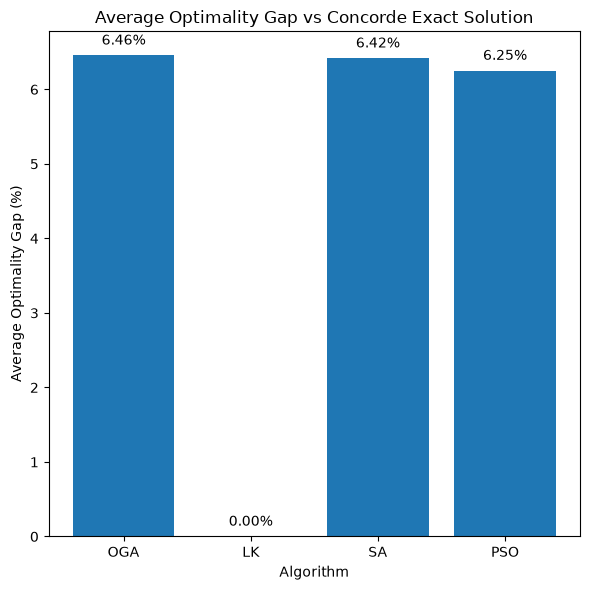

In [34]:
algos = ['OGA', 'LK', 'SA', 'PSO']
avg_gaps = [summary_df[f'{algo}_gap_%'].mean() for algo in algos]
plt.figure(figsize=(6,6))
bars = plt.bar(algos, avg_gaps)

for bar, gap in zip(bars, avg_gaps):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{gap:.2f}%", ha="center", va="bottom")
plt.ylabel("Average Optimality Gap (%)")
plt.xlabel("Algorithm")
plt.title("Average Optimality Gap vs Concorde Exact Solution")
plt.tight_layout()
plt.savefig("avg_gap.png")
plt.show()

In [25]:
def add_rankings(df, algos=["OGA","SA","LK","PSO"]):
    cost_cols = [f"[algo]_best_cost" for algo in algos]

    for i, row in df.iterrows():
        costs = {algo: row[f"{algo}_best_cost"] for algo in algos}
        ranked = sorted(costs, key=costs.get)
        for rank, algo in enumerate(ranked):
            df.at[i, f"{algo}_rank"] = rank + 1

    return df

train_df = add_rankings(pd.read_csv("train_meta.csv"))
val_df = add_rankings(pd.read_csv("val_meta.csv"))

### ML Model Training and Validation

In [16]:
FEATURES = [
    "n_cities",
    "noise_factor",
    "distance_type",
    "triangle_violation_rate",
    "instance_type",
    "avg_edge",
    "std_edge",
    "cv_edge",
    "skew_edge",
    "kurtosis_edge",
    "min_edge",
    "max_edge",
    "avg_nn",
    "std_nn",
    "cv_nn",
    "skew_nn",
    "mst_cost",
    "avg_mst_edge",
    "std_mst_edge",
    "mst_nn_ratio"]

TARGET = "best_algo"
len(FEATURES)

20

In [17]:
train_df = pd.read_csv("train_meta.csv")
val_df = pd.read_csv("val_meta.csv")

X_train = train_df[FEATURES].fillna(0)
y_train = train_df[TARGET]

X_val = val_df[FEATURES].fillna(0)
y_val = val_df[TARGET]

print(X_train.shape, y_train.unique())

(5760, 20) <StringArray>
['OGA', 'LK', 'SA', 'PSO']
Length: 4, dtype: str


In [15]:
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=90, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=90),
}

results = {}
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    cv = cross_val_score(model, X_train, y_train, cv=5).mean()
    results[name] = {"train_acc": train_acc, "cv_acc": cv, "val_acc": val_acc}
    print(f"{name:20} | fit_time={fit_time:.3f}s | train={train_acc:.3f} | cv={cv:.3f} | val={val_acc:.3f}")

results_df = pd.DataFrame(results).T
print(results_df)

RandomForest         | fit_time=1.226s | train=0.926 | cv=0.657 | val=0.857
GradientBoosting     | fit_time=9.295s | train=0.927 | cv=0.686 | val=0.894
                  train_acc    cv_acc   val_acc
RandomForest       0.926042  0.657465  0.856848
GradientBoosting   0.927257  0.685590  0.893540


In [18]:
clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=90, class_weight="balanced")

clf.fit(X_train, y_train)
cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=90)
cv_scores = cross_val_score(clf, X_train, y_train, cv=skf)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

CV Accuracy: 0.657 +/- 0.227
CV Accuracy: 0.808 +/- 0.010


In [22]:
single_instance = X_train.iloc[[0]]
times = []
for i in range(100):
    t0 = time.perf_counter()
    i = clf.predict(single_instance)
    t1 = time.perf_counter()
    times.append(t1-t0)
print(f"Mean single-instance predicion time: {np.mean(times)*1000:.3f} ms")
print(f"Std: {np.std(times)*1000:.3f} ms")

Mean single-instance predicion time: 10.388 ms
Std: 2.212 ms


In [29]:
val_preds = clf.predict(X_val)
print(val_preds.shape)

(1935,)


Validation Accuracy=0.857
Classification Report
              precision    recall  f1-score   support

          LK       0.98      0.92      0.95      1685
         OGA       0.43      0.43      0.43       126
         PSO       0.32      0.44      0.37        63
          SA       0.14      0.30      0.19        61

    accuracy                           0.86      1935
   macro avg       0.47      0.52      0.49      1935
weighted avg       0.89      0.86      0.87      1935

Confusion Matrix


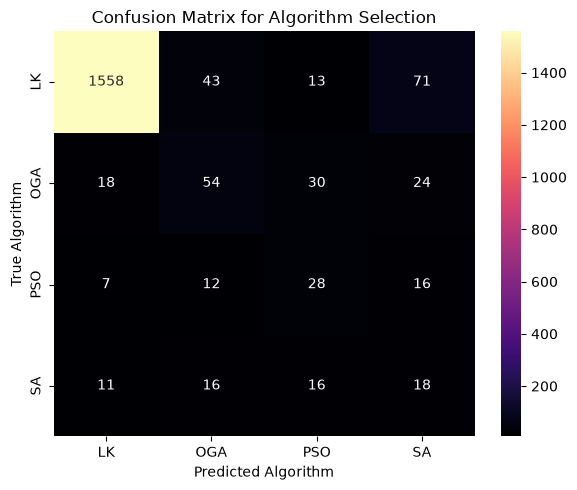

In [15]:
val_preds = clf.predict(X_val)
labels = clf.classes_
print(f"Validation Accuracy={accuracy_score(y_val, val_preds):.3f}")
print("Classification Report")
print(classification_report(y_val, val_preds, zero_division=0))
print("Confusion Matrix")
cm = confusion_matrix(y_val, val_preds, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Algorithm")
plt.ylabel("True Algorithm")
plt.title("Confusion Matrix for Algorithm Selection")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
     

In [16]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.head(15))

mst_cost         0.105671
n_cities         0.088769
distance_type    0.065014
cv_edge          0.061806
avg_mst_edge     0.051285
skew_edge        0.050726
max_edge         0.048600
mst_nn_ratio     0.048502
std_mst_edge     0.048444
kurtosis_edge    0.047623
std_edge         0.047247
std_nn           0.045236
noise_factor     0.044993
avg_edge         0.044692
skew_nn          0.042518
dtype: float64


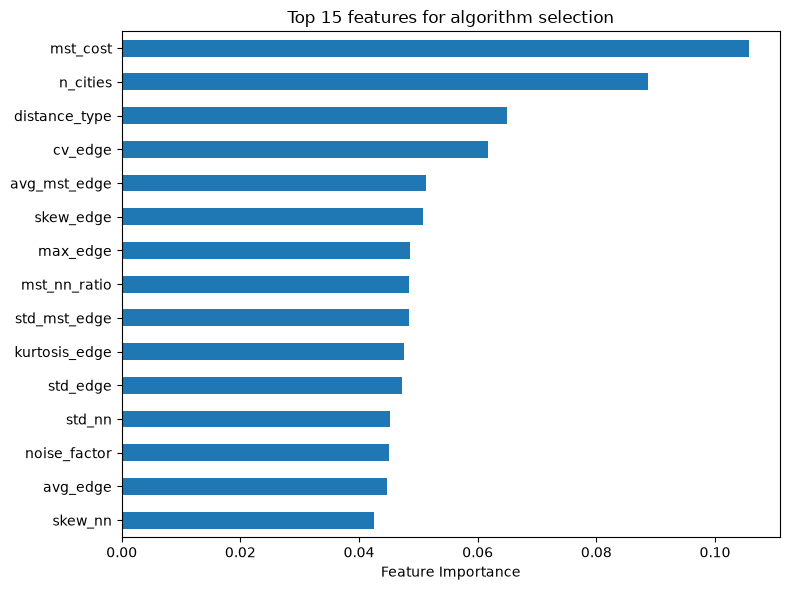

In [17]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 features for algorithm selection")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [28]:
clf_grad = GradientBoostingClassifier(n_estimators=200, random_state=90)

clf_grad.fit(X_train, y_train)
cv_scores = cross_val_score(clf_grad, X_train, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

skf_grad = StratifiedKFold(n_splits=5, shuffle=True, random_state=90)
cv_scores = cross_val_score(clf_grad, X_train, y_train, cv=skf_grad)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

CV Accuracy: 0.686 +/- 0.231
CV Accuracy: 0.846 +/- 0.007


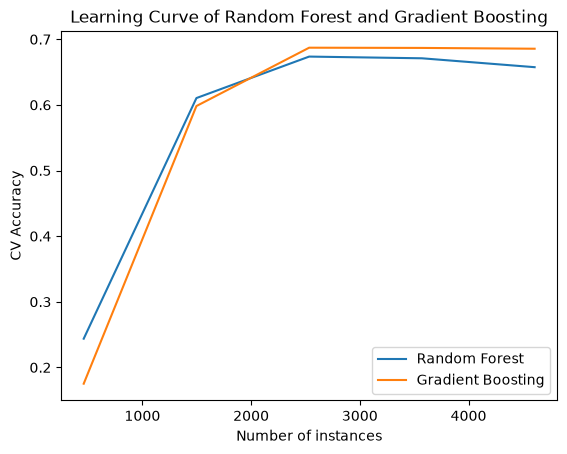

In [29]:
train_sizes, train_scores, val_scores = learning_curve(clf, X_train, y_train, cv=5)
train_sizes1, train_scores1, val_scores1 = learning_curve(clf_grad, X_train, y_train, cv=5)
plt.plot(train_sizes, val_scores.mean(axis=1), label="Random Forest")
plt.plot(train_sizes1, val_scores1.mean(axis=1), label="Gradient Boosting")
plt.xlabel("Number of instances")
plt.ylabel("CV Accuracy")
plt.title("Learning Curve of Random Forest and Gradient Boosting")
plt.legend()
plt.savefig("learning_curve_comb.png")

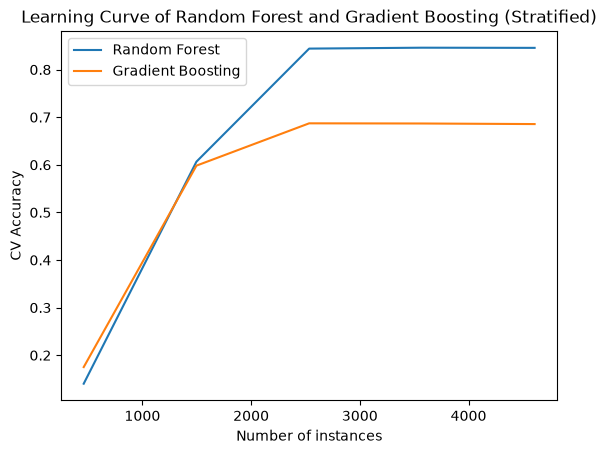

In [30]:
train_sizes, train_scores, val_scores = learning_curve(clf, X_train, y_train, cv=skf)
train_sizes, train_scores, val_scores = learning_curve(clf_grad, X_train, y_train, cv=skf_grad)
plt.plot(train_sizes, val_scores.mean(axis=1), label="Random Forest")
plt.plot(train_sizes1, val_scores1.mean(axis=1), label="Gradient Boosting")
plt.xlabel("Number of instances")
plt.ylabel("CV Accuracy")
plt.title("Learning Curve of Random Forest and Gradient Boosting (Stratified)")
plt.legend()
plt.savefig("learning_curve_skf_comb.png")

Validation Accuracy=0.894
Classification Report
              precision    recall  f1-score   support

          LK       0.95      0.98      0.96      1685
         OGA       0.50      0.38      0.43       126
         PSO       0.43      0.38      0.40        63
          SA       0.10      0.07      0.08        61

    accuracy                           0.89      1935
   macro avg       0.49      0.45      0.47      1935
weighted avg       0.88      0.89      0.88      1935

Confusion Matrix


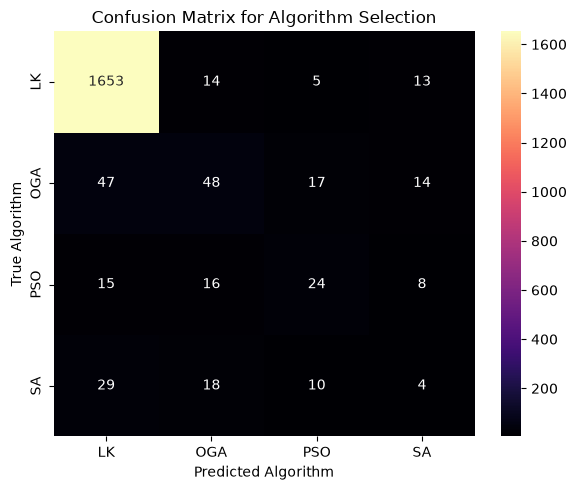

In [26]:
val_preds = clf_grad.predict(X_val)
labels = clf_grad.classes_
print(f"Validation Accuracy={accuracy_score(y_val, val_preds):.3f}")
print("Classification Report")
print(classification_report(y_val, val_preds, zero_division=0))
print("Confusion Matrix")
cm = confusion_matrix(y_val, val_preds, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Algorithm")
plt.ylabel("True Algorithm")
plt.title("Confusion Matrix for Algorithm Selection")
plt.tight_layout()
plt.savefig("confusion_matrix_grad.png")
plt.show()

In [28]:
importances = pd.Series(clf_grad.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.head(15))

n_cities                   0.533719
mst_cost                   0.056661
avg_edge                   0.050629
mst_nn_ratio               0.036346
skew_nn                    0.034531
max_edge                   0.033824
triangle_violation_rate    0.030588
cv_edge                    0.027514
kurtosis_edge              0.027224
std_nn                     0.024914
skew_edge                  0.023063
avg_nn                     0.021538
std_edge                   0.021305
min_edge                   0.020301
cv_nn                      0.016655
dtype: float64


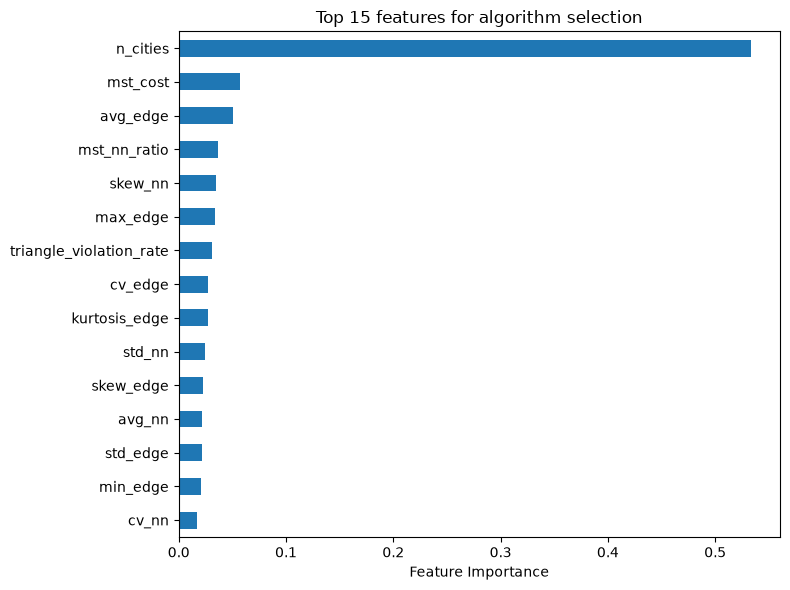

In [29]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 features for algorithm selection")
plt.tight_layout()
plt.savefig("feature_importance_grad.png")
plt.show()

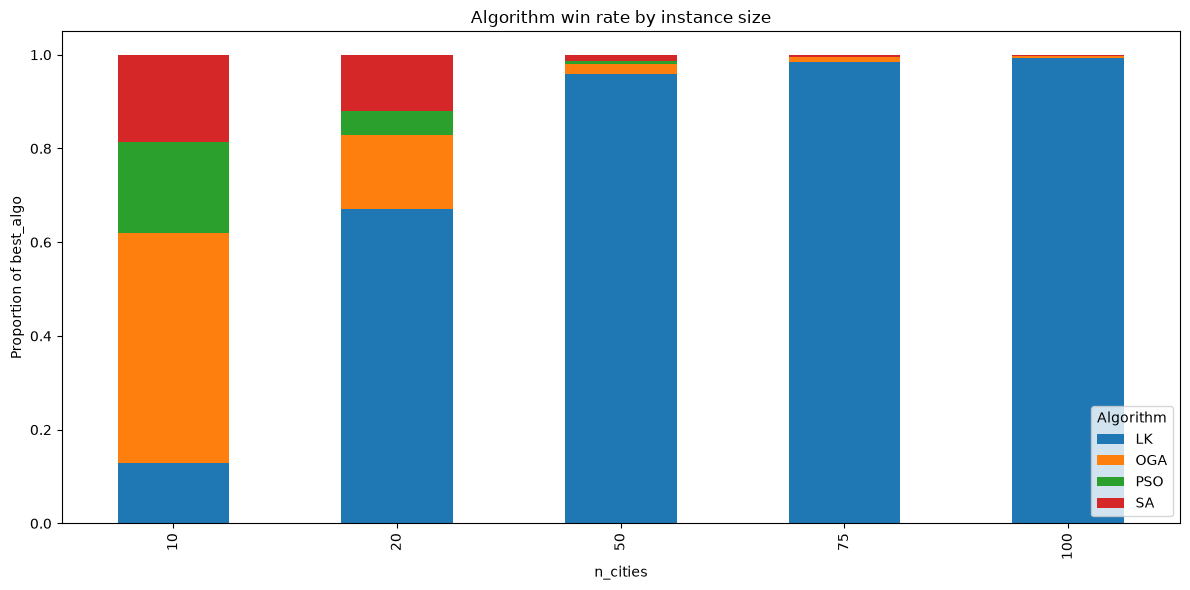

In [16]:
train_df.groupby("n_cities")["best_algo"].value_counts(normalize=True).unstack().plot(
    kind="bar", stacked=True, figsize=(12,6))
plt.ylabel("Proportion of best_algo")
plt.title("Algorithm win rate by instance size")
plt.legend(title="Algorithm")
plt.tight_layout()
plt.savefig("algo_win_rate.png")
plt.show()

### Removal of Lin-Kernighan Study

In [19]:
def get_algo_pool(n):
    if n<=30:
        epochs, pop = 200,100
    elif n<=75:
        epochs, pop = 300,100
    elif n<=100:
        epochs, pop = 400,100
    else:
        epochs, pop = 500,150
        
    return {
        "OGA": lambda D, e=epochs, p=pop: run_mealpy(GA.OriginalGA(epoch=e, pop_size=p), D),
        "SA":  lambda D, e=epochs: run_mealpy(SA.OriginalSA(epoch=e, pop_size=10), D),
        "PSO": lambda D, e=epochs, p=pop: run_mealpy(PSO.OriginalPSO(epoch=e, pop_size=p), D),
    }

In [20]:
build_dataset(train_configs_10_20, source="generated", use_concorde=False, output_file="train_10_20.csv")

[1/1920] uniform_10_0_euclidean_random_cost -> best: PSO
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[3/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[5/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[6/1920] uniform_10_0_euclidean_triangle_violation -> best: OGA
[7/1920] uniform_10_0_manhattan_random_cost -> best: PSO
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: PSO
[9/1920] uniform_10_0_manhattan_random_cost -> best: SA
[10/1920] uniform_10_0_manhattan_triangle_violation -> best: OGA
[11/1920] uniform_10_0_manhattan_random_cost -> best: SA
[12/1920] uniform_10_0_manhattan_triangle_violation -> best: OGA
[13/1920] uniform_10_0_ceil_euclidean_random_cost -> best: OGA
[14/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: PSO
[15/1920] uniform_10_0_ceil_euclidean_random_cost -> best: OGA
[16/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: SA
[17/1920] 

/tmp/ipykernel_1723/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/1920] grid_10_0_euclidean_random_cost -> best: OGA
[482/1920] grid_10_0_euclidean_triangle_violation -> best: PSO
[483/1920] grid_10_0_euclidean_random_cost -> best: PSO
[484/1920] grid_10_0_euclidean_triangle_violation -> best: PSO
[485/1920] grid_10_0_euclidean_random_cost -> best: PSO
[486/1920] grid_10_0_euclidean_triangle_violation -> best: SA
[487/1920] grid_10_0_manhattan_random_cost -> best: OGA
[488/1920] grid_10_0_manhattan_triangle_violation -> best: OGA
[489/1920] grid_10_0_manhattan_random_cost -> best: OGA
[490/1920] grid_10_0_manhattan_triangle_violation -> best: SA
[491/1920] grid_10_0_manhattan_random_cost -> best: PSO
[492/1920] grid_10_0_manhattan_triangle_violation -> best: OGA
[493/1920] grid_10_0_ceil_euclidean_random_cost -> best: OGA
[494/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: PSO
[495/1920] grid_10_0_ceil_euclidean_random_cost -> best: SA
[496/1920] grid_10_0_ceil_euclidean_triangle_violation -> best: SA
[497/1920] grid_10_0_ceil_euclid

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,OGA_std_cost,OGA_avg_time,SA_best_cost,SA_avg_cost,SA_std_cost,SA_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,10,0.0,0,0.000000,1,595.698975,277.547799,0.465920,0.009372,-1.116216,...,0.000000e+00,0.025584,2940.041676,2940.041676,0.000000e+00,0.015989,2940.041676,2940.041676,2.625485e-13,0.581730
1,10,0.0,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,6.143517e+02,0.018297,4682.118054,4682.118054,7.425993e-13,0.013842,4682.118054,4682.118054,5.250970e-13,0.572030
2,10,0.1,0,0.000000,1,623.356820,277.059482,0.444464,0.038744,-1.127442,...,6.431099e-13,0.018940,3243.555563,3243.555563,2.625485e-13,0.014101,3243.555563,3243.555563,2.625485e-13,0.567681
3,10,0.1,0,0.208333,2,1629.643045,1149.079322,0.705111,0.616437,-1.044734,...,8.624612e+02,0.019284,4682.118054,5424.770659,5.473988e+02,0.014576,4682.118054,5116.530281,6.143517e+02,0.570974
4,10,0.2,0,0.000000,1,651.014664,277.029516,0.425535,0.065891,-1.133819,...,4.547474e-13,0.017128,3547.069451,3547.069451,4.547474e-13,0.130741,3547.069451,3547.069451,4.547474e-13,0.574334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,20,0.0,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,1.285120e+02,0.027695,5876.007042,6155.413946,2.014752e+02,0.019101,5693.665008,6022.380842,2.837588e+02,0.871590
1916,20,0.1,2,0.005263,1,397.027715,249.105738,0.627427,0.444126,-0.912146,...,2.458474e+01,0.023255,2533.745438,2539.146791,3.819333e+00,0.018600,2533.187723,2556.460051,2.702095e+01,0.878004
1917,20,0.1,2,0.206433,2,1416.781265,1166.851733,0.823593,0.903504,-0.602433,...,2.950812e+02,0.027050,5799.001993,5964.765143,1.271177e+02,0.019123,5693.665008,6049.367231,2.688317e+02,0.861750
1918,20,0.2,2,0.005556,1,414.812698,248.689528,0.599522,0.444439,-0.902505,...,1.999456e-01,0.025843,2881.033916,2899.665208,2.634863e+01,0.020422,2880.609767,2886.080942,7.439507e+00,0.897389


In [21]:
build_dataset(train_configs_50, source="generated", use_concorde=False, output_file="train_50.csv")

[1/1920] uniform_50_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_50_0_euclidean_random_cost -> best: SA
[3/1920] uniform_50_0_euclidean_triangle_violation -> best: PSO
[4/1920] uniform_50_0_euclidean_triangle_violation -> best: OGA
[5/1920] uniform_50_0_euclidean_random_cost -> best: PSO
[6/1920] uniform_50_0_euclidean_random_cost -> best: PSO
[7/1920] uniform_50_0_euclidean_triangle_violation -> best: OGA
[8/1920] uniform_50_0_euclidean_triangle_violation -> best: PSO
[9/1920] uniform_50_0_euclidean_random_cost -> best: SA
[10/1920] uniform_50_0_euclidean_random_cost -> best: OGA
[11/1920] uniform_50_0_euclidean_triangle_violation -> best: PSO
[12/1920] uniform_50_0_euclidean_triangle_violation -> best: PSO
[13/1920] uniform_50_0_manhattan_random_cost -> best: PSO
[14/1920] uniform_50_0_manhattan_random_cost -> best: OGA
[15/1920] uniform_50_0_manhattan_triangle_violation -> best: OGA
[16/1920] uniform_50_0_manhattan_triangle_violation -> best: SA
[17/1920] uniform_50_0_manha

/tmp/ipykernel_1723/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[961/1920] grid_50_0_euclidean_random_cost -> best: OGA
[962/1920] grid_50_0_euclidean_random_cost -> best: SA
[963/1920] grid_50_0_euclidean_triangle_violation -> best: OGA
[964/1920] grid_50_0_euclidean_triangle_violation -> best: OGA
[965/1920] grid_50_0_euclidean_random_cost -> best: OGA
[966/1920] grid_50_0_euclidean_random_cost -> best: PSO
[967/1920] grid_50_0_euclidean_triangle_violation -> best: SA
[968/1920] grid_50_0_euclidean_triangle_violation -> best: PSO
[969/1920] grid_50_0_euclidean_random_cost -> best: PSO
[970/1920] grid_50_0_euclidean_random_cost -> best: OGA
[971/1920] grid_50_0_euclidean_triangle_violation -> best: SA
[972/1920] grid_50_0_euclidean_triangle_violation -> best: OGA
[973/1920] grid_50_0_manhattan_random_cost -> best: SA
[974/1920] grid_50_0_manhattan_random_cost -> best: SA
[975/1920] grid_50_0_manhattan_triangle_violation -> best: SA
[976/1920] grid_50_0_manhattan_triangle_violation -> best: OGA
[977/1920] grid_50_0_manhattan_random_cost -> best: OG

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,OGA_std_cost,OGA_avg_time,SA_best_cost,SA_avg_cost,SA_std_cost,SA_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,181.967978,0.058557,5815.555596,5860.544316,45.247449,0.035593,5708.176963,6008.990246,337.358314,1.614019
1,50,0.0,0,0.000000,1,539.513805,251.422019,0.466016,0.145777,-0.717523,...,153.417543,0.049905,5665.771923,5800.190758,104.802426,0.036385,5678.085405,5842.754653,183.059443,1.629359
2,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,332.693311,0.052624,9273.356742,9570.682279,295.899523,0.040055,9108.298453,9267.587104,161.405732,1.569161
3,50,0.0,0,0.207310,2,1409.298156,1229.898986,0.872703,1.089602,-0.103573,...,447.640112,0.051516,8999.726138,9262.971047,186.746171,0.030130,9204.496587,9600.575293,452.311013,1.595689
4,50,0.1,0,0.001754,1,566.031233,251.196022,0.443785,0.144875,-0.708832,...,169.516497,0.053507,7348.343131,7622.076211,194.065156,0.030937,6929.013992,7027.436539,78.939315,1.612506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,50,0.1,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,165.554362,0.045404,9095.880005,9339.091127,173.346985,0.030553,9141.878313,9226.986937,60.248789,1.610968
1916,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,5.743575,0.058086,4006.172564,4041.256348,43.315375,0.049605,4052.598321,4073.686228,18.003166,1.594263
1917,50,0.2,2,0.011988,1,390.854736,241.540456,0.617980,0.584559,-0.482199,...,36.299432,0.047119,3984.764743,4024.109751,34.281209,0.030638,4007.648696,4038.827724,24.860744,1.431346
1918,50,0.2,2,0.199415,2,1314.388817,1129.020148,0.858970,1.131855,0.041797,...,419.783931,0.047053,9068.167181,9405.068638,291.291819,0.028833,8971.768610,9587.621107,488.188203,1.476292


In [22]:
build_dataset(train_configs_75, source="generated", use_concorde=False, output_file="train_75.csv")

[1/960] uniform_75_0_euclidean_random_cost -> best: PSO
[2/960] uniform_75_0_euclidean_triangle_violation -> best: OGA
[3/960] uniform_75_0_euclidean_random_cost -> best: PSO
[4/960] uniform_75_0_euclidean_triangle_violation -> best: PSO
[5/960] uniform_75_0_euclidean_random_cost -> best: PSO
[6/960] uniform_75_0_euclidean_triangle_violation -> best: OGA
[7/960] uniform_75_0_manhattan_random_cost -> best: PSO
[8/960] uniform_75_0_manhattan_triangle_violation -> best: SA
[9/960] uniform_75_0_manhattan_random_cost -> best: SA
[10/960] uniform_75_0_manhattan_triangle_violation -> best: OGA
[11/960] uniform_75_0_manhattan_random_cost -> best: OGA
[12/960] uniform_75_0_manhattan_triangle_violation -> best: OGA
[13/960] uniform_75_0_ceil_euclidean_random_cost -> best: SA
[14/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: OGA
[15/960] uniform_75_0_ceil_euclidean_random_cost -> best: PSO
[16/960] uniform_75_0_ceil_euclidean_triangle_violation -> best: PSO
[17/960] uniform_75_0_ce

/tmp/ipykernel_1723/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_75_0_euclidean_random_cost -> best: SA
[482/960] grid_75_0_euclidean_triangle_violation -> best: OGA
[483/960] grid_75_0_euclidean_random_cost -> best: SA
[484/960] grid_75_0_euclidean_triangle_violation -> best: OGA
[485/960] grid_75_0_euclidean_random_cost -> best: OGA
[486/960] grid_75_0_euclidean_triangle_violation -> best: OGA
[487/960] grid_75_0_manhattan_random_cost -> best: PSO
[488/960] grid_75_0_manhattan_triangle_violation -> best: PSO
[489/960] grid_75_0_manhattan_random_cost -> best: SA
[490/960] grid_75_0_manhattan_triangle_violation -> best: PSO
[491/960] grid_75_0_manhattan_random_cost -> best: OGA
[492/960] grid_75_0_manhattan_triangle_violation -> best: SA
[493/960] grid_75_0_ceil_euclidean_random_cost -> best: SA
[494/960] grid_75_0_ceil_euclidean_triangle_violation -> best: OGA
[495/960] grid_75_0_ceil_euclidean_random_cost -> best: PSO
[496/960] grid_75_0_ceil_euclidean_triangle_violation -> best: SA
[497/960] grid_75_0_ceil_euclidean_random_cost -> 

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,OGA_std_cost,OGA_avg_time,SA_best_cost,SA_avg_cost,SA_std_cost,SA_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,75,0.0,0,0.000000,1,502.186874,242.731839,0.483350,0.313081,-0.546283,...,164.475390,0.065645,7565.700401,7576.664704,11.723026,0.031591,7390.767651,7695.314006,215.350446,1.740830
1,75,0.0,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,254.737687,0.058069,10642.449647,10799.058854,148.769809,0.031567,10735.819885,11157.026846,451.099858,2.056745
2,75,0.1,0,0.003509,1,526.886931,242.700428,0.460631,0.313733,-0.540354,...,135.303830,0.077109,9524.578837,9747.210741,157.743325,0.032267,9428.180678,9549.626164,85.902082,1.803295
3,75,0.1,0,0.204386,2,1351.048212,1172.657889,0.867962,1.169233,0.201152,...,472.435584,0.068781,10491.108064,10923.143247,305.714065,0.033431,10226.185152,10494.855437,344.703398,1.830275
4,75,0.2,0,0.006140,1,551.586988,243.099677,0.440728,0.312310,-0.531617,...,149.177965,0.059397,10966.410942,11118.110247,107.269517,0.030621,10942.814363,11095.455350,209.623545,1.911192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,75,0.0,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,229.148794,0.097448,10698.426010,11460.877394,539.281635,0.036066,10967.887235,11075.873085,120.529725,2.007203
956,75,0.1,2,0.014620,1,371.842327,236.170368,0.635136,0.529603,-0.655180,...,39.345128,0.063566,3913.643563,3948.950051,25.011324,0.032465,3890.186333,3918.324312,22.518308,1.745594
957,75,0.1,2,0.196199,2,1248.444067,1089.025289,0.872306,1.202531,0.283261,...,307.543059,0.059653,9913.307110,10393.592112,342.037743,0.031162,10690.298724,11207.613882,379.445546,1.884967
958,75,0.2,2,0.017251,1,389.160160,236.592981,0.607958,0.527748,-0.653366,...,16.018336,0.070822,4849.154229,4965.020815,91.422587,0.032291,4838.236846,4897.694461,59.076522,1.845344


In [23]:
build_dataset(train_configs_100, source="generated", use_concorde=False, output_file="train_100.csv")

[1/960] uniform_100_0_euclidean_random_cost -> best: SA
[2/960] uniform_100_0_euclidean_triangle_violation -> best: PSO
[3/960] uniform_100_0_euclidean_random_cost -> best: SA
[4/960] uniform_100_0_euclidean_triangle_violation -> best: PSO
[5/960] uniform_100_0_euclidean_random_cost -> best: PSO
[6/960] uniform_100_0_euclidean_triangle_violation -> best: SA
[7/960] uniform_100_0_manhattan_random_cost -> best: SA
[8/960] uniform_100_0_manhattan_triangle_violation -> best: PSO
[9/960] uniform_100_0_manhattan_random_cost -> best: OGA
[10/960] uniform_100_0_manhattan_triangle_violation -> best: SA
[11/960] uniform_100_0_manhattan_random_cost -> best: SA
[12/960] uniform_100_0_manhattan_triangle_violation -> best: SA
[13/960] uniform_100_0_ceil_euclidean_random_cost -> best: SA
[14/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: PSO
[15/960] uniform_100_0_ceil_euclidean_random_cost -> best: OGA
[16/960] uniform_100_0_ceil_euclidean_triangle_violation -> best: PSO
[17/960] unif

/tmp/ipykernel_1723/3902276500.py:39: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew_nn": float(skew(nn)),


[481/960] grid_100_0_euclidean_random_cost -> best: SA
[482/960] grid_100_0_euclidean_triangle_violation -> best: PSO
[483/960] grid_100_0_euclidean_random_cost -> best: PSO
[484/960] grid_100_0_euclidean_triangle_violation -> best: SA
[485/960] grid_100_0_euclidean_random_cost -> best: PSO
[486/960] grid_100_0_euclidean_triangle_violation -> best: SA
[487/960] grid_100_0_manhattan_random_cost -> best: PSO
[488/960] grid_100_0_manhattan_triangle_violation -> best: SA
[489/960] grid_100_0_manhattan_random_cost -> best: PSO
[490/960] grid_100_0_manhattan_triangle_violation -> best: SA
[491/960] grid_100_0_manhattan_random_cost -> best: SA
[492/960] grid_100_0_manhattan_triangle_violation -> best: PSO
[493/960] grid_100_0_ceil_euclidean_random_cost -> best: PSO
[494/960] grid_100_0_ceil_euclidean_triangle_violation -> best: PSO
[495/960] grid_100_0_ceil_euclidean_random_cost -> best: SA
[496/960] grid_100_0_ceil_euclidean_triangle_violation -> best: PSO
[497/960] grid_100_0_ceil_euclidean

/home/shawn/MSc Project/MLA/venv/lib/python3.11/site-packages/mealpy/optimizer.py:287: RuntimeWarning: invalid value encountered in divide
  self.history.list_exploration = 100 * (np.array(self.history.list_diversity) / div_max)


[838/960] diagonal_100_4_chebyshev_triangle_violation -> best: PSO
[839/960] diagonal_100_4_chebyshev_random_cost -> best: OGA
[840/960] diagonal_100_4_chebyshev_triangle_violation -> best: PSO
[841/960] diagonal_100_5_euclidean_random_cost -> best: PSO
[842/960] diagonal_100_5_euclidean_triangle_violation -> best: SA
[843/960] diagonal_100_5_euclidean_random_cost -> best: PSO
[844/960] diagonal_100_5_euclidean_triangle_violation -> best: SA
[845/960] diagonal_100_5_euclidean_random_cost -> best: SA
[846/960] diagonal_100_5_euclidean_triangle_violation -> best: PSO
[847/960] diagonal_100_5_manhattan_random_cost -> best: SA
[848/960] diagonal_100_5_manhattan_triangle_violation -> best: OGA
[849/960] diagonal_100_5_manhattan_random_cost -> best: SA
[850/960] diagonal_100_5_manhattan_triangle_violation -> best: PSO
[851/960] diagonal_100_5_manhattan_random_cost -> best: SA
[852/960] diagonal_100_5_manhattan_triangle_violation -> best: PSO
[853/960] diagonal_100_5_ceil_euclidean_random_cos

,n_cities,noise_factor,distance_type,triangle_violation_rate,instance_type,avg_edge,std_edge,cv_edge,skew_edge,kurtosis_edge,...,OGA_std_cost,OGA_avg_time,SA_best_cost,SA_avg_cost,SA_std_cost,SA_avg_time,PSO_best_cost,PSO_avg_cost,PSO_std_cost,PSO_avg_time
0,100,0.0,0,0.000000,1,512.148774,245.275643,0.478915,0.184677,-0.700335,...,12.372873,0.101932,8000.489466,8184.502470,130.329319,0.044870,8065.121406,8230.501957,144.369530,2.707633
1,100,0.0,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,258.615215,0.114551,12619.499903,12991.582558,389.993505,0.051058,12258.003815,12704.024884,411.231130,3.293605
2,100,0.1,0,0.001170,1,537.783235,245.470622,0.456449,0.183074,-0.698210,...,173.890789,0.125556,10195.496311,10434.595854,169.085932,0.055030,10513.103218,10632.275831,162.814956,3.020755
3,100,0.1,0,0.210526,2,1354.212715,1180.341684,0.871607,1.183240,0.207989,...,178.009599,0.098984,13379.357246,13547.194335,187.228608,0.044017,12526.862337,13163.052575,450.385190,2.758418
4,100,0.2,0,0.002047,1,563.417695,246.090104,0.436781,0.180459,-0.691736,...,111.564032,0.100445,12558.990132,12632.448471,62.739322,0.047978,12335.951038,12579.245632,176.361474,2.729395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,100,0.0,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,289.339594,0.094851,12045.017787,12074.404519,26.287869,0.042262,11893.221954,12127.716498,195.551029,2.603228
956,100,0.1,2,0.009942,1,369.376211,235.757487,0.638258,0.465841,-0.820081,...,122.585948,-0.172839,4446.484358,4480.578459,24.171361,0.042630,4481.818027,4505.749902,17.680005,2.672373
957,100,0.1,2,0.195322,2,1242.294477,1091.944771,0.878974,1.214154,0.333492,...,235.896442,0.097369,11581.581152,11856.021265,280.433711,0.075441,11354.257790,11954.506222,429.627750,3.252322
958,100,0.2,2,0.012573,1,386.627895,236.082916,0.610620,0.461961,-0.819447,...,27.942046,0.120248,5780.417007,5818.135644,41.053324,0.057451,5796.455969,5814.236106,12.606794,3.003098


In [24]:
files = [ "train_10_20.csv", "train_50.csv", "train_75.csv", "train_100.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
train_df = pd.concat(dfs, ignore_index=True)
train_df.to_csv("train_meta.csv", index=False)

In [25]:
TSPLIB_SMALL = ["att48", "bayg29", "burma14","bays29", "gr17", "gr21", "gr48"]
TSPLIB_MED = ["eil51", "berlin52", "st70", "eil76","brazil58"]
TSPLIB_LARGE = ["kroA100", "eil101", "lin105"]
val_configs_synthetic = [
    {"n": n, "distribution": d, "seed": s, "distance_type": dt, "noise_factor": nf, "instance_type": it}
    for n in range(10,101,10)
    for d in ["uniform","clustered", "grid","diagonal"]
    for s in range(3)
    for dt in ["euclidean","manhattan","ceil_euclidean","chebyshev"]
    for nf in [0.1, 0.2]
    for it in ["random_cost","triangle_violation"]
]


In [26]:
val_df_small = build_dataset([{"name": p} for p in TSPLIB_SMALL], source="tsplib", use_concorde=False, output_file="val_small.csv")
val_df_med = build_dataset([{"name": p} for p in TSPLIB_MED], source="tsplib", use_concorde=False, output_file="val_med.csv")
val_df_large = build_dataset([{"name": p} for p in TSPLIB_LARGE], source="tsplib", use_concorde=False, output_file="val_large.csv")
val_df_synthetic = build_dataset(val_configs_synthetic, source="generated", use_concorde=False, output_file="val_synthetic.csv")

[1/7] att48 -> best: PSO
[2/7] bayg29 -> best: OGA
[3/7] burma14 -> best: SA
[4/7] bays29 -> best: PSO
[5/7] gr17 -> best: OGA
[6/7] gr21 -> best: OGA
[7/7] gr48 -> best: SA
[1/5] eil51 -> best: SA
[2/5] berlin52 -> best: PSO
[3/5] st70 -> best: OGA
[4/5] eil76 -> best: SA
[5/5] brazil58 -> best: PSO
[1/3] kroA100 -> best: SA
[2/3] eil101 -> best: OGA
[3/3] lin105 -> best: SA
[1/1920] uniform_10_0_euclidean_random_cost -> best: OGA
[2/1920] uniform_10_0_euclidean_triangle_violation -> best: SA
[3/1920] uniform_10_0_euclidean_random_cost -> best: PSO
[4/1920] uniform_10_0_euclidean_triangle_violation -> best: PSO
[5/1920] uniform_10_0_manhattan_random_cost -> best: PSO
[6/1920] uniform_10_0_manhattan_triangle_violation -> best: SA
[7/1920] uniform_10_0_manhattan_random_cost -> best: PSO
[8/1920] uniform_10_0_manhattan_triangle_violation -> best: SA
[9/1920] uniform_10_0_ceil_euclidean_random_cost -> best: OGA
[10/1920] uniform_10_0_ceil_euclidean_triangle_violation -> best: SA
[11/1920]

/home/shawn/MSc Project/MLA/venv/lib/python3.11/site-packages/mealpy/optimizer.py:287: RuntimeWarning: invalid value encountered in divide
  self.history.list_exploration = 100 * (np.array(self.history.list_diversity) / div_max)


[1381/1920] uniform_80_2_manhattan_random_cost -> best: OGA
[1382/1920] uniform_80_2_manhattan_triangle_violation -> best: PSO
[1383/1920] uniform_80_2_manhattan_random_cost -> best: SA
[1384/1920] uniform_80_2_manhattan_triangle_violation -> best: SA
[1385/1920] uniform_80_2_ceil_euclidean_random_cost -> best: OGA
[1386/1920] uniform_80_2_ceil_euclidean_triangle_violation -> best: OGA
[1387/1920] uniform_80_2_ceil_euclidean_random_cost -> best: PSO
[1388/1920] uniform_80_2_ceil_euclidean_triangle_violation -> best: OGA
[1389/1920] uniform_80_2_chebyshev_random_cost -> best: PSO
[1390/1920] uniform_80_2_chebyshev_triangle_violation -> best: PSO
[1391/1920] uniform_80_2_chebyshev_random_cost -> best: PSO
[1392/1920] uniform_80_2_chebyshev_triangle_violation -> best: PSO
[1393/1920] clustered_80_0_euclidean_random_cost -> best: PSO
[1394/1920] clustered_80_0_euclidean_triangle_violation -> best: SA
[1395/1920] clustered_80_0_euclidean_random_cost -> best: SA
[1396/1920] clustered_80_0_eu

In [27]:
files = ["val_small.csv","val_med.csv","val_large.csv","val_synthetic.csv"]
dfs = []
for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        dfs.append(df)
val_df = pd.concat(dfs, ignore_index=True)
val_df.to_csv("val_meta.csv", index=False)

In [29]:
def add_rankings(df, algos=["OGA","SA","PSO"]):
    cost_cols = [f"[algo]_best_cost" for algo in algos]

    for i, row in df.iterrows():
        costs = {algo: row[f"{algo}_best_cost"] for algo in algos}
        ranked = sorted(costs, key=costs.get)
        for rank, algo in enumerate(ranked):
            df.at[i, f"{algo}_rank"] = rank + 1

    return df

train_df = add_rankings(pd.read_csv("train_meta.csv"))
val_df = add_rankings(pd.read_csv("val_meta.csv"))

In [30]:
train_df = pd.read_csv("train_meta.csv")
val_df = pd.read_csv("val_meta.csv")

X_train = train_df[FEATURES].fillna(0)
y_train = train_df[TARGET]

X_val = val_df[FEATURES].fillna(0)
y_val = val_df[TARGET]

print(X_train.shape, y_train.unique())

(5760, 20) <StringArray>
['PSO', 'SA', 'OGA']
Length: 3, dtype: str


In [35]:
clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=90)

clf.fit(X_train, y_train)
cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")


CV Accuracy: 0.283 +/- 0.078


Validation Accuracy=0.341
Classification Report
              precision    recall  f1-score   support

         OGA       0.38      0.31      0.35       690
         PSO       0.33      0.37      0.35       613
          SA       0.32      0.34      0.33       632

    accuracy                           0.34      1935
   macro avg       0.34      0.34      0.34      1935
weighted avg       0.34      0.34      0.34      1935

Confusion Matrix


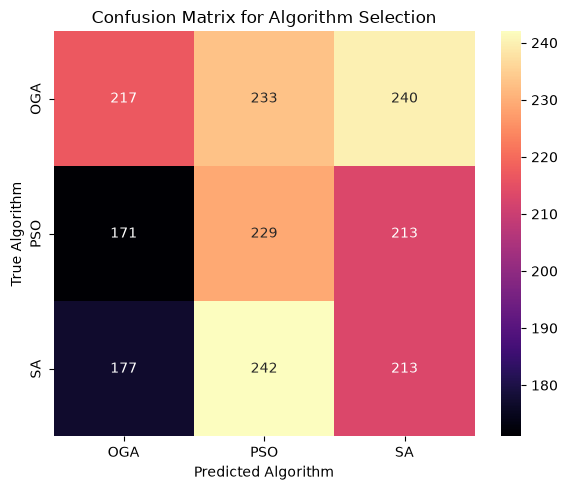

In [32]:
val_preds = clf.predict(X_val)
labels = clf.classes_
print(f"Validation Accuracy={accuracy_score(y_val, val_preds):.3f}")
print("Classification Report")
print(classification_report(y_val, val_preds, zero_division=0))
print("Confusion Matrix")
cm = confusion_matrix(y_val, val_preds, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Algorithm")
plt.ylabel("True Algorithm")
plt.title("Confusion Matrix for Algorithm Selection")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
     

In [33]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.head(15))

distance_type    0.147164
noise_factor     0.105454
mst_cost         0.051450
skew_nn          0.050886
min_edge         0.049089
kurtosis_edge    0.048203
cv_edge          0.046298
avg_edge         0.045803
mst_nn_ratio     0.045557
cv_nn            0.045102
skew_edge        0.044936
std_mst_edge     0.044702
max_edge         0.044616
std_edge         0.043985
avg_nn           0.043867
dtype: float64


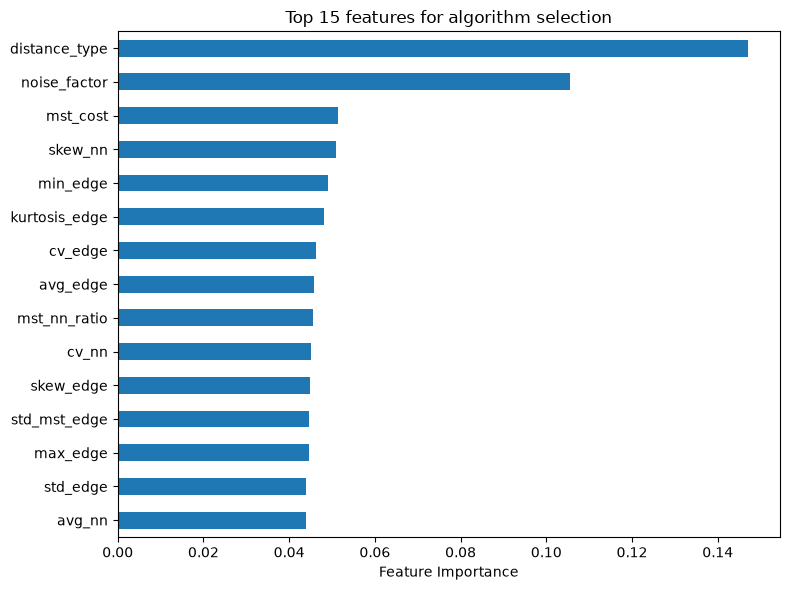

In [34]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 15 features for algorithm selection")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [38]:
train_df["cost_spread"] = train_df[["OGA_best_cost", "SA_best_cost", "PSO_best_cost"]].std(axis=1)
train_df["cost_spread_pct"] = train_df["cost_spread"] / train_df[["OGA_best_cost", "SA_best_cost", "PSO_best_cost"]].mean(axis=1) * 100

print(train_df["cost_spread_pct"].describe())

count    5760.000000
mean        1.475724
std         1.534033
min         0.000000
25%         0.315077
50%         1.056835
75%         2.241786
max        17.832775
Name: cost_spread_pct, dtype: float64


In [39]:
similar_scores = (train_df["cost_spread_pct"]<2.0).mean() * 100
print(f"Instances with <2% spread between the algorithms: {similar_scores:.1f}%")
dominant = (train_df["cost_spread_pct"] >= 5.0).mean() * 100
print(f"Instances with >=5% spread between the algorithms: {dominant:.1f}%")

Instances with <2% spread between the algorithms: 71.0%
Instances with >=5% spread between the algorithms: 2.8%


In [25]:
def runtime_benchmark(clf, cities_size, n_repeats=5):
    results = []
    for n in cities_size:
        times = []
        for i in range(n_repeats):
            coords, D = generate_instance(n,"uniform", seed=np.random.randint(0,1000))
            t0 = time.perf_counter()
            features = extract_features(coords, D, distance_type="euclidean",noise_factor=0.0, instance_type="standard")
            X = pd.DataFrame([features])[FEATURES].fillna(0)
            i = clf.predict(X)
            t1 = time.perf_counter()
            times.append(t1-t0)
        
        results.append({"n_cities":n,"mean_time_ms": np.mean(times)*1000,"std_time_ms":np.std(times)*1000})
    return pd.DataFrame(results)

benchmark_df = runtime_benchmark(clf, cities_size=[10,50,75,100])
print(benchmark_df.to_string(index=False))

 n_cities  mean_time_ms  std_time_ms
       10     15.404944     1.646948
       50     16.743576     1.015442
       75     15.040324     0.295179
      100     16.310678     1.084386


### Runtime Analysis 

In [26]:
avg_algo_runtime = train_df[["OGA_avg_time","SA_avg_time","LK_avg_time","PSO_avg_time"]].mean(axis=1).mean()
total_portfolio_runtime = train_df[["OGA_avg_time","SA_avg_time","LK_avg_time","PSO_avg_time"]].sum(axis=1).mean()

print(f"Average runtime if running all 4 algorithms per instance: {total_portfolio_runtime:.3f}s")
print(f"Average runtime if running only the RF-predicted algorithm: {avg_algo_runtime:.3f}s")

Average runtime if running all 4 algorithms per instance: 2.123s
Average runtime if running only the RF-predicted algorithm: 0.531s
